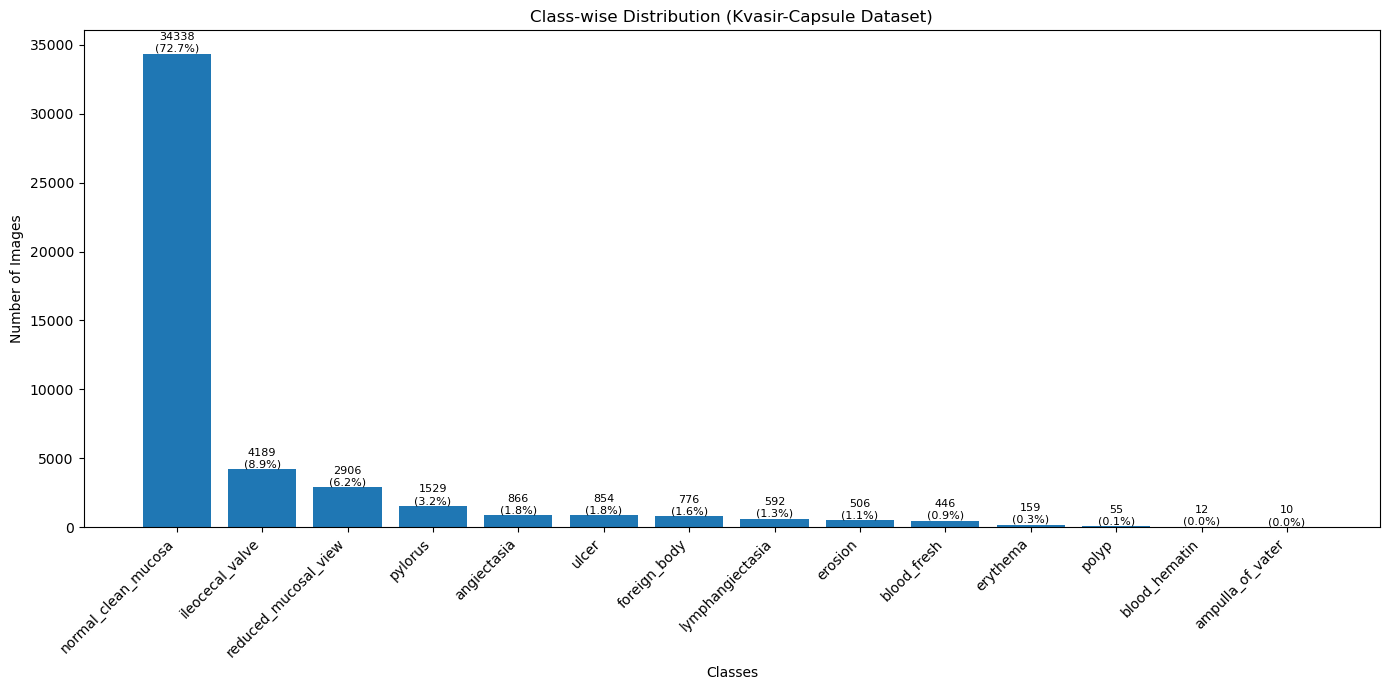

Majority class: normal_clean_mucosa
Minority class: ampulla_of_vater


In [8]:
import os
import matplotlib.pyplot as plt

dataset_path = r"C:\Users\Krishna Mehra\Desktop\dlproject\labelled_images"

class_counts = {}

# Count images recursively
for cls in os.listdir(dataset_path):
    cls_path = os.path.join(dataset_path, cls)

    if os.path.isdir(cls_path):
        image_count = 0
        for root, dirs, files in os.walk(cls_path):
            for f in files:
                if f.lower().endswith(('.png', '.jpg', '.jpeg')):
                    image_count += 1

        class_counts[cls] = image_count

# Remove empty classes (just in case)
class_counts = {k: v for k, v in class_counts.items() if v > 0}

# Sort
class_counts = dict(sorted(class_counts.items(), key=lambda x: x[1], reverse=True))

# Total images
total_images = sum(class_counts.values())

# Plot
plt.figure(figsize=(14,7))
bars = plt.bar(class_counts.keys(), class_counts.values())

plt.xticks(rotation=45, ha='right')
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.title("Class-wise Distribution (Kvasir-Capsule Dataset)")

# Add values + percentage on bars
for bar in bars:
    height = bar.get_height()
    percentage = (height / total_images) * 100
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f'{int(height)}\n({percentage:.1f}%)',
             ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# Majority & Minority
majority_class = max(class_counts, key=class_counts.get)
minority_class = min(class_counts, key=class_counts.get)

print("Majority class:", majority_class)
print("Minority class:", minority_class)

TASK 1 

Class imbalance is a significant issue in medical image datasets such as the Kvasir-Capsule dataset, where some classes contain a large number of images while others have very few. This imbalance can cause machine learning models to become biased toward majority classes, leading to poor detection of rare but clinically important conditions. As a result, the model may achieve high accuracy but fail in critical diagnoses. In medical applications, such errors can have serious consequences for patient care. Therefore, handling class imbalance is essential to ensure reliable and fair model performance. Techniques such as data augmentation, resampling, and weighted loss functions are commonly used to address this problem.

TASK 2

Majority classes → too many images
Minority classes → keep all images
Fix → reduce majority to max 200 images/class

New class distribution: {'ampulla_of_vater': 10, 'angiectasia': 200, 'blood_fresh': 200, 'blood_hematin': 12, 'erosion': 200, 'erythema': 159, 'foreign_body': 200, 'ileocecal_valve': 200, 'lymphangiectasia': 200, 'normal_clean_mucosa': 200, 'polyp': 55, 'pylorus': 200, 'reduced_mucosal_view': 200, 'ulcer': 200}


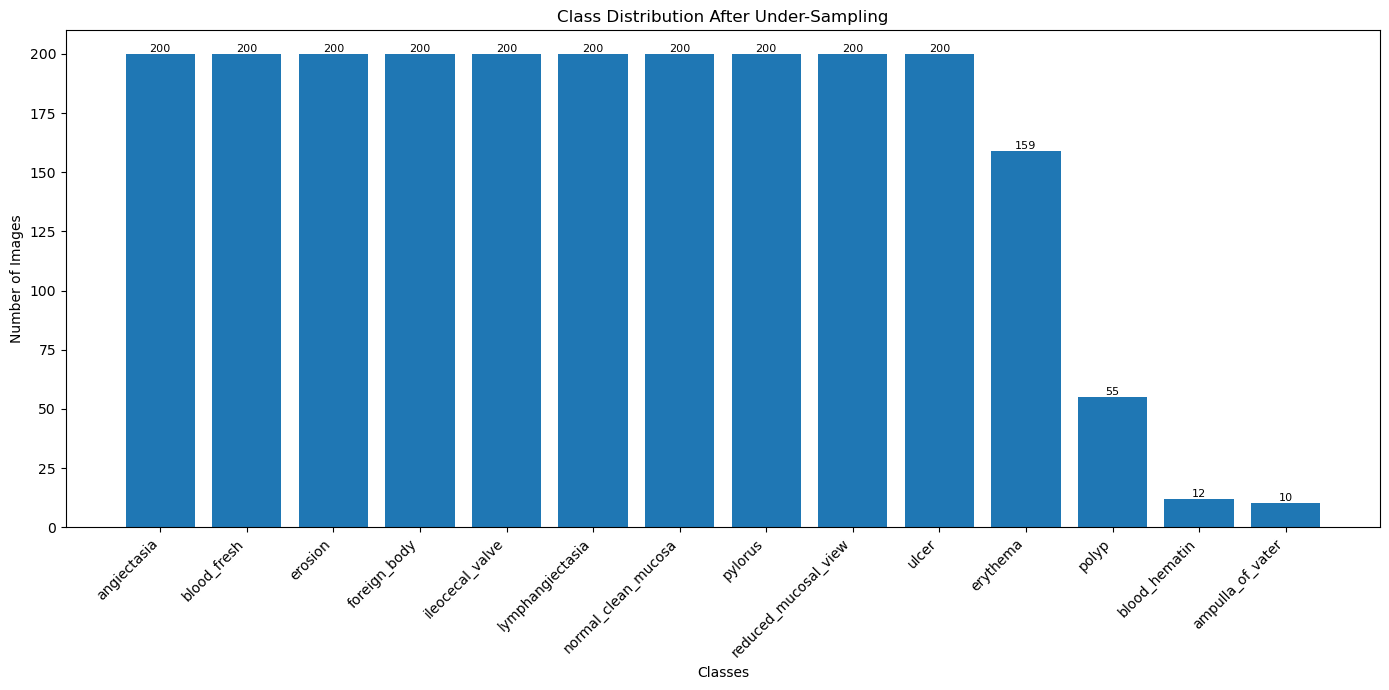

In [9]:
import os
import random
import shutil
import matplotlib.pyplot as plt
input_path = r"C:\Users\Krishna Mehra\Desktop\dlproject\labelled_images"
output_path = r"C:\Users\Krishna Mehra\Desktop\dlproject\undersampled_dataset"

threshold = 200  # max images per class

# Create output directory
os.makedirs(output_path, exist_ok=True)

new_class_counts = {}

# =========================
# 🔄 Under-sampling process
# =========================
for cls in os.listdir(input_path):
    cls_path = os.path.join(input_path, cls)

    if os.path.isdir(cls_path):
        all_images = []

        # Collect images recursively
        for root, dirs, files in os.walk(cls_path):
            for f in files:
                if f.lower().endswith(('.png', '.jpg', '.jpeg')):
                    all_images.append(os.path.join(root, f))

        # Shuffle randomly
        random.shuffle(all_images)

        # Apply threshold
        if len(all_images) > threshold:
            selected_images = all_images[:threshold]
        else:
            selected_images = all_images  # keep all minority

        # Create class folder in output
        new_cls_path = os.path.join(output_path, cls)
        os.makedirs(new_cls_path, exist_ok=True)

        # Copy selected images
        for img_path in selected_images:
            img_name = os.path.basename(img_path)
            shutil.copy(img_path, os.path.join(new_cls_path, img_name))

        new_class_counts[cls] = len(selected_images)

print("New class distribution:", new_class_counts)

# =========================
# 📊 Plot new distribution
# =========================
new_class_counts = dict(sorted(new_class_counts.items(), key=lambda x: x[1], reverse=True))

plt.figure(figsize=(14,7))
bars = plt.bar(new_class_counts.keys(), new_class_counts.values())

plt.xticks(rotation=45, ha='right')
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.title("Class Distribution After Under-Sampling")

# Add values
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f'{int(height)}',
             ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

Under-sampling reduces the dominance of majority classes by limiting the number of samples to a fixed threshold. This helps in balancing the dataset and prevents the model from becoming biased toward frequently occurring classes. However, an important drawback is the loss of potentially useful data, as many samples from majority classes are discarded. While this improves class balance, it may reduce the model’s ability to generalize well on those classes. Therefore, under-sampling involves a trade-off between dataset balance and information loss. It is often combined with other techniques like augmentation to achieve better performance.

TASK 3 

Data Augmentation–Based Over-Sampling

In [ ]:
import os
import random
import shutil
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 📌 Paths
input_path = r"C:\Users\Krishna Mehra\Desktop\dlproject\labelled_images"
output_path = r"C:\Users\Krishna Mehra\Desktop\dlproject\augmented_dataset"

threshold = 200
os.makedirs(output_path, exist_ok=True)

# =========================
# 🎨 Augmentation Functions
# =========================
def augment_image(img):
    h, w = img.shape[:2]

    # Random horizontal flip
    if random.random() > 0.5:
        img = cv2.flip(img, 1)

    # Rotation ±20°
    angle = random.uniform(-20, 20)
    M = cv2.getRotationMatrix2D((w//2, h//2), angle, 1)
    img = cv2.warpAffine(img, M, (w, h))

    # Width & height shift
    tx = random.uniform(-0.2*w, 0.2*w)
    ty = random.uniform(-0.2*h, 0.2*h)
    M = np.float32([[1, 0, tx], [0, 1, ty]])
    img = cv2.warpAffine(img, M, (w, h))

    # Zoom
    scale = random.uniform(0.8, 1.2)
    img = cv2.resize(img, None, fx=scale, fy=scale)

    # Resize back to fixed size
    img = cv2.resize(img, (224, 224))

    return img

# =========================
# 🔄 Augmentation Process
# =========================
updated_counts = {}

for cls in os.listdir(input_path):
    cls_path = os.path.join(input_path, cls)

    if os.path.isdir(cls_path):
        images = []

        # Collect images
        for root, dirs, files in os.walk(cls_path):
            for f in files:
                if f.lower().endswith(('.png', '.jpg', '.jpeg')):
                    images.append(os.path.join(root, f))

        new_cls_path = os.path.join(output_path, cls)
        os.makedirs(new_cls_path, exist_ok=True)

        # Copy originals
        for img_path in images:
            shutil.copy(img_path, os.path.join(new_cls_path, os.path.basename(img_path)))

        count = len(images)

        # Apply augmentation for minority
        if count < threshold:
            needed = threshold - count

            for i in range(needed):
                img_path = random.choice(images)

                img = cv2.imread(img_path)
                img = cv2.resize(img, (224, 224))

                aug_img = augment_image(img)

                aug_name = f"aug_{i}_{os.path.basename(img_path)}"
                cv2.imwrite(os.path.join(new_cls_path, aug_name), aug_img)

        updated_counts[cls] = max(count, threshold)

print("Updated dataset:", updated_counts)

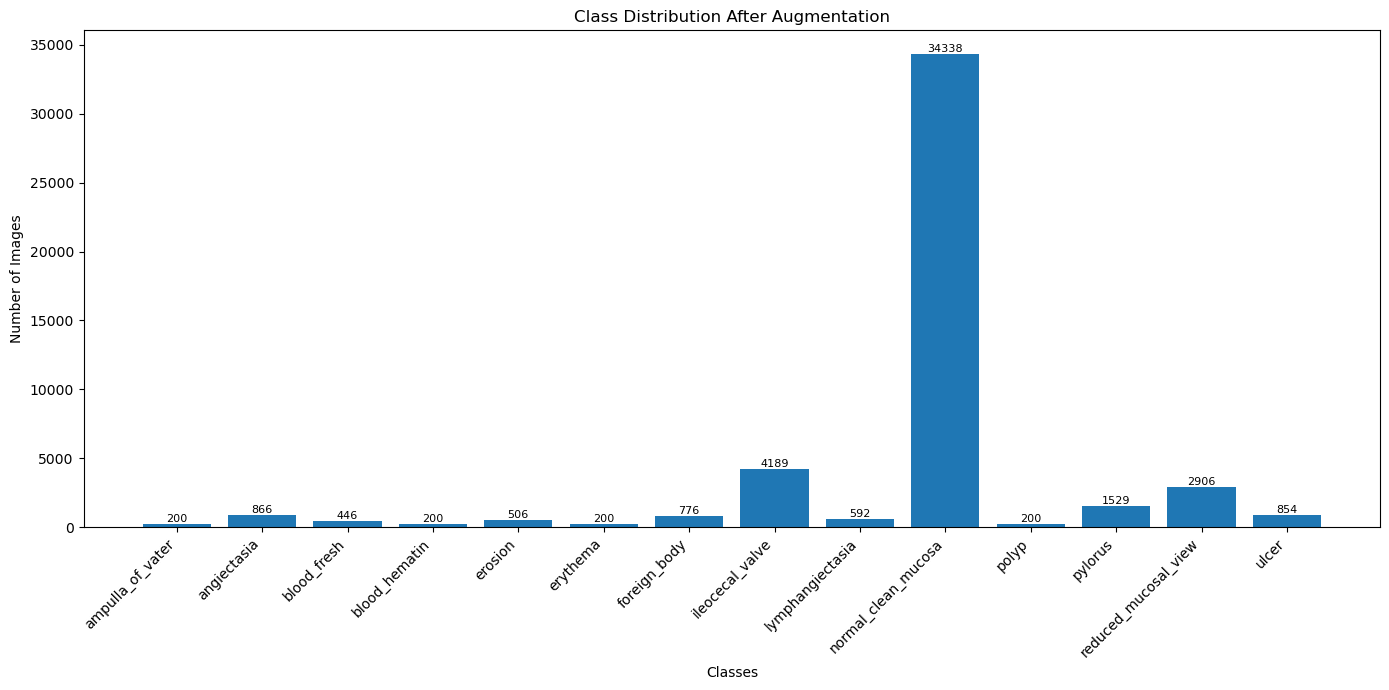

In [ ]:
plt.figure(figsize=(14,7))
bars = plt.bar(updated_counts.keys(), updated_counts.values())

plt.xticks(rotation=45, ha='right')
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.title("Class Distribution After Augmentation")

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f'{int(height)}',
             ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

HYBRID APPROACH 
OVER-SAMPLING OF MINORITY OF 400 SAMPLES EACH 
AND UNDERSAMPLING OF MAJORITY TO 15 PERCENT OF ORIGINAL AMOUNT

In [ ]:
import os
import random
import shutil
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 📌 Paths
input_path = r"C:\Users\Krishna Mehra\Desktop\dlproject\labelled_images"
output_path = r"C:\Users\Krishna Mehra\Desktop\dlproject\hybrid_dataset"

os.makedirs(output_path, exist_ok=True)

TARGET_MIN = 400
MAJORITY_REDUCTION = 0.15

# =========================
# 🎨 Augmentation Function
# =========================
def augment_image(img):
    h, w = img.shape[:2]

    # Flip
    if random.random() > 0.5:
        img = cv2.flip(img, 1)

    # Rotation
    angle = random.uniform(-20, 20)
    M = cv2.getRotationMatrix2D((w//2, h//2), angle, 1)
    img = cv2.warpAffine(img, M, (w, h))

    # Shift
    tx = random.uniform(-0.2*w, 0.2*w)
    ty = random.uniform(-0.2*h, 0.2*h)
    M = np.float32([[1, 0, tx], [0, 1, ty]])
    img = cv2.warpAffine(img, M, (w, h))

    # Zoom
    scale = random.uniform(0.8, 1.2)
    img = cv2.resize(img, None, fx=scale, fy=scale)

    # Resize (faster)
    img = cv2.resize(img, (128, 128))

    return img

# =========================
# 🔄 Hybrid Processing
# =========================
final_counts = {}

for cls in os.listdir(input_path):
    cls_path = os.path.join(input_path, cls)

    if not os.path.isdir(cls_path):
        continue

    print(f"\nProcessing class: {cls}")

    images = []

    for root, dirs, files in os.walk(cls_path):
        for f in files:
            if f.lower().endswith(('.png', '.jpg', '.jpeg')):
                images.append(os.path.join(root, f))

    random.shuffle(images)
    count = len(images)

    print(f"Original count: {count}")

    new_cls_path = os.path.join(output_path, cls)
    os.makedirs(new_cls_path, exist_ok=True)

    # 🔻 Downsample
    if count > TARGET_MIN:
        new_count = int(count * MAJORITY_REDUCTION)
        selected = images[:new_count]
        print(f"Downsampled to: {new_count}")
    else:
        selected = images
        print("Minority class")

    # Copy originals
    for img_path in selected:
        shutil.copy(img_path, os.path.join(new_cls_path, os.path.basename(img_path)))

    current_count = len(selected)

    # 🔺 Augmentation
    if current_count < TARGET_MIN:
        needed = TARGET_MIN - current_count
        print(f"Augmenting {needed} images...")

        for i in range(needed):
            img_path = random.choice(selected)

            img = cv2.imread(img_path)
            img = cv2.resize(img, (128, 128))

            aug_img = augment_image(img)

            aug_name = f"aug_{i}.jpg"
            cv2.imwrite(os.path.join(new_cls_path, aug_name), aug_img)

            # Progress print
            if i % 50 == 0:
                print(f"{cls}: {i}/{needed}")

        final_counts[cls] = TARGET_MIN
    else:
        final_counts[cls] = current_count

    print(f"✅ Done: {cls}")

print("\nFinal distribution:", final_counts)


➡️ Processing class: ampulla_of_vater
Original count: 10
Minority class
Augmenting 390 images...
ampulla_of_vater: 0/390
ampulla_of_vater: 50/390
ampulla_of_vater: 100/390
ampulla_of_vater: 150/390
ampulla_of_vater: 200/390
ampulla_of_vater: 250/390
ampulla_of_vater: 300/390
ampulla_of_vater: 350/390
✅ Done: ampulla_of_vater

➡️ Processing class: angiectasia
Original count: 866
Downsampled to: 129
Augmenting 271 images...
angiectasia: 0/271
angiectasia: 50/271
angiectasia: 100/271
angiectasia: 150/271
angiectasia: 200/271
angiectasia: 250/271
✅ Done: angiectasia

➡️ Processing class: blood_fresh
Original count: 446
Downsampled to: 66
Augmenting 334 images...
blood_fresh: 0/334
blood_fresh: 50/334
blood_fresh: 100/334
blood_fresh: 150/334
blood_fresh: 200/334
blood_fresh: 250/334
blood_fresh: 300/334
✅ Done: blood_fresh

➡️ Processing class: blood_hematin
Original count: 12
Minority class
Augmenting 388 images...
blood_hematin: 0/388
blood_hematin: 50/388
blood_hematin: 100/388
blood_h

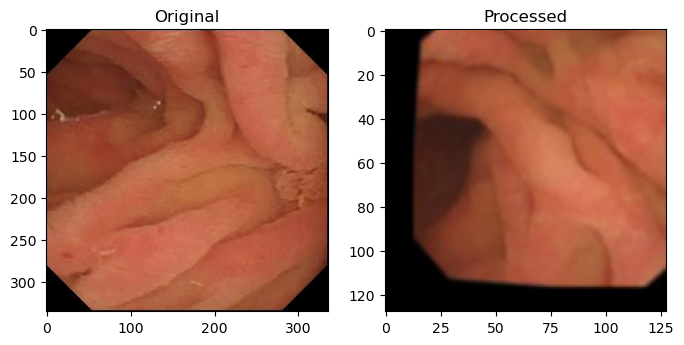

In [2]:
sample_class = list(final_counts.keys())[0]

orig_img = cv2.imread(random.choice([
    os.path.join(root, f)
    for root, _, files in os.walk(os.path.join(input_path, sample_class))
    for f in files if f.endswith(('.jpg','.png','.jpeg'))
]))

aug_img = cv2.imread(os.path.join(output_path, sample_class,
                                  random.choice(os.listdir(os.path.join(output_path, sample_class)))))

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB))
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(aug_img, cv2.COLOR_BGR2RGB))
plt.title("Processed")

plt.show()

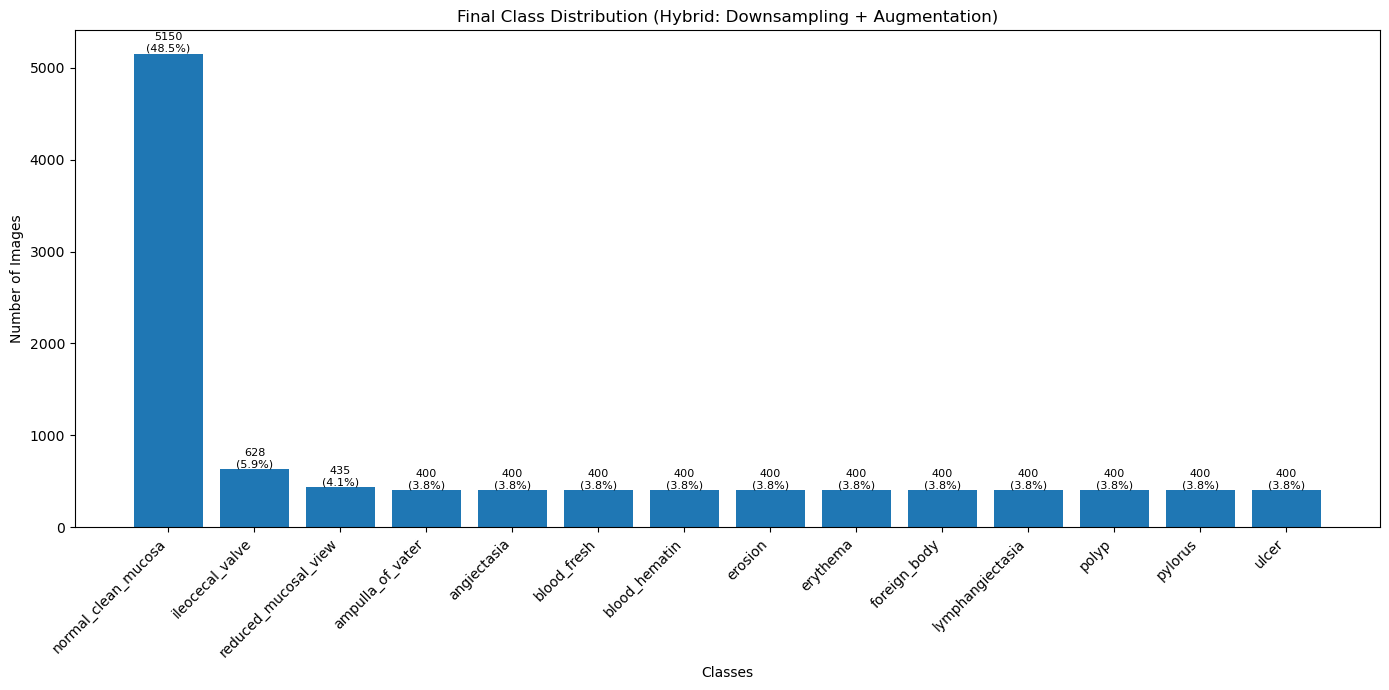

In [3]:
import matplotlib.pyplot as plt

# Sort for better visualization
final_counts = dict(sorted(final_counts.items(), key=lambda x: x[1], reverse=True))

total_images = sum(final_counts.values())

plt.figure(figsize=(14,7))
bars = plt.bar(final_counts.keys(), final_counts.values())

plt.xticks(rotation=45, ha='right')
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.title("Final Class Distribution (Hybrid: Downsampling + Augmentation)")

# Add labels + percentage
for bar in bars:
    height = bar.get_height()
    percentage = (height / total_images) * 100
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f'{int(height)}\n({percentage:.1f}%)',
             ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

In [6]:
import os

def get_dataset_info(path):
    total_images = 0
    total_size = 0  # in bytes

    for root, dirs, files in os.walk(path):
        for f in files:
            if f.lower().endswith(('.png', '.jpg', '.jpeg')):
                total_images += 1
                file_path = os.path.join(root, f)
                total_size += os.path.getsize(file_path)

    # Convert size
    size_mb = total_size / (1024 * 1024)
    size_gb = total_size / (1024 * 1024 * 1024)

    return total_images, size_mb, size_gb


# 📌 Paths (UPDATE if needed)
undersampled_path = r"C:\Users\Krishna Mehra\Desktop\dlproject\undersampled_dataset"
augmented_path = r"C:\Users\Krishna Mehra\Desktop\dlproject\augmented_dataset"
hybrid_path = r"C:\Users\Krishna Mehra\Desktop\dlproject\hybrid_dataset"

# Get info
u_imgs, u_mb, u_gb = get_dataset_info(undersampled_path)
a_imgs, a_mb, a_gb = get_dataset_info(augmented_path)
h_imgs, h_mb, h_gb = get_dataset_info(hybrid_path)

print("\n📊 DATASET SUMMARY\n")

print(f"Under-sampled Dataset:")
print(f"Images: {u_imgs}, Size: {u_mb:.2f} MB ({u_gb:.2f} GB)\n")

print(f"Augmented Dataset:")
print(f"Images: {a_imgs}, Size: {a_mb:.2f} MB ({a_gb:.2f} GB)\n")

print(f"Hybrid Dataset:")
print(f"Images: {h_imgs}, Size: {h_mb:.2f} MB ({h_gb:.2f} GB)\n")

import pandas as pd

data = {
    "Dataset": ["Under-sampled", "Augmented", "Hybrid"],
    "Images": [u_imgs, a_imgs, h_imgs],
    "Size (MB)": [round(u_mb,2), round(a_mb,2), round(h_mb,2)]
}

df = pd.DataFrame(data)
print(df)


📊 DATASET SUMMARY

Under-sampled Dataset:
Images: 3822, Size: 46.11 MB (0.05 GB)

Augmented Dataset:
Images: 48324, Size: 574.09 MB (0.56 GB)

Hybrid Dataset:
Images: 11375, Size: 110.85 MB (0.11 GB)

         Dataset  Images  Size (MB)
0  Under-sampled    3822      46.11
1      Augmented   48324     574.09
2         Hybrid   11375     110.85


The under-sampled dataset has the smallest size due to reduction of majority class samples, resulting in lower storage requirements but potential information loss. The augmented dataset has a significantly larger size as new synthetic images are generated to balance minority classes, increasing storage but improving data diversity. The hybrid dataset provides a balance between the two approaches by reducing excessive samples from majority classes and augmenting minority classes, leading to a moderately sized dataset with improved class balance and efficient storage utilization.

TASK - 4 Data Pre-Processing

In [9]:
import os
import random
import shutil
import cv2
import numpy as np

# 📌 Input datasets
datasets = {
    "undersampled": r"C:\Users\Krishna Mehra\Desktop\dlproject\undersampled_dataset",
    "augmented": r"C:\Users\Krishna Mehra\Desktop\dlproject\augmented_dataset",
    "hybrid": r"C:\Users\Krishna Mehra\Desktop\dlproject\hybrid_dataset"
}

# 📌 Output base folder
output_base = r"C:\Users\Krishna Mehra\Desktop\dlproject\processed_datasets"

# Split ratios
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15


# =========================
# 🔄 Function to process one dataset
# =========================
def process_dataset(name, input_path):
    print(f"\n🚀 Processing dataset: {name}")

    output_path = os.path.join(output_base, name)

    for split in ["train", "val", "test"]:
        os.makedirs(os.path.join(output_path, split), exist_ok=True)

    for cls in os.listdir(input_path):
        cls_path = os.path.join(input_path, cls)

        if not os.path.isdir(cls_path):
            continue

        images = [
            os.path.join(cls_path, f)
            for f in os.listdir(cls_path)
            if f.lower().endswith(('.png','.jpg','.jpeg'))
        ]

        random.shuffle(images)
        total = len(images)

        train_end = int(train_ratio * total)
        val_end = train_end + int(val_ratio * total)

        splits = {
            "train": images[:train_end],
            "val": images[train_end:val_end],
            "test": images[val_end:]
        }

        for split_name, split_imgs in splits.items():
            split_cls_path = os.path.join(output_path, split_name, cls)
            os.makedirs(split_cls_path, exist_ok=True)

            for img_path in split_imgs:
                img = cv2.imread(img_path)

                # Resize
                img = cv2.resize(img, (224, 224))

                # Normalize
                img = img / 255.0

                # Convert back for saving
                img = (img * 255).astype(np.uint8)

                save_path = os.path.join(split_cls_path, os.path.basename(img_path))
                cv2.imwrite(save_path, img)

        print(f"✅ {name} - {cls} done")

    print(f"🎯 Finished: {name}")


# =========================
# 🔥 Run for all datasets
# =========================
for name, path in datasets.items():
    process_dataset(name, path)

print("\n🔥 ALL DATASETS PREPROCESSED SUCCESSFULLY")


🚀 Processing dataset: undersampled
✅ undersampled - ampulla_of_vater done
✅ undersampled - angiectasia done
✅ undersampled - blood_fresh done
✅ undersampled - blood_hematin done
✅ undersampled - erosion done
✅ undersampled - erythema done
✅ undersampled - foreign_body done
✅ undersampled - ileocecal_valve done
✅ undersampled - lymphangiectasia done
✅ undersampled - normal_clean_mucosa done
✅ undersampled - polyp done
✅ undersampled - pylorus done
✅ undersampled - reduced_mucosal_view done
✅ undersampled - ulcer done
🎯 Finished: undersampled

🚀 Processing dataset: augmented
✅ augmented - ampulla_of_vater done
✅ augmented - angiectasia done
✅ augmented - blood_fresh done
✅ augmented - blood_hematin done
✅ augmented - erosion done
✅ augmented - erythema done
✅ augmented - foreign_body done
✅ augmented - ileocecal_valve done
✅ augmented - lymphangiectasia done
✅ augmented - normal_clean_mucosa done
✅ augmented - polyp done
✅ augmented - pylorus done
✅ augmented - reduced_mucosal_view done

In [10]:
def count_images(path):
    total = 0
    for root, _, files in os.walk(path):
        total += len([f for f in files if f.endswith(('.jpg','.png','.jpeg'))])
    return total

for name in ["undersampled", "augmented", "hybrid"]:
    base = os.path.join(output_base, name)

    train = count_images(os.path.join(base, "train"))
    val = count_images(os.path.join(base, "val"))
    test = count_images(os.path.join(base, "test"))

    print(f"\n{name.upper()}")
    print(f"Train: {train}")
    print(f"Val: {val}")
    print(f"Test: {test}")


UNDERSAMPLED
Train: 2669
Val: 565
Test: 588

AUGMENTED
Train: 33821
Val: 7241
Test: 7262

HYBRID
Train: 7959
Val: 1703
Test: 1713


In [25]:
import os
import random
import shutil
import cv2
import numpy as np

# 📌 Input (ORIGINAL imbalanced dataset)
input_path = r"C:\Users\Krishna Mehra\Desktop\dlproject\labelled_images"

# 📌 Output
output_path = r"C:\Users\Krishna Mehra\Desktop\dlproject\processed_datasets\imbalanced"

# Split ratios
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

# Create folders
for split in ["train", "val", "test"]:
    os.makedirs(os.path.join(output_path, split), exist_ok=True)

# =========================
# 🔄 Processing
# =========================
for cls in os.listdir(input_path):
    cls_path = os.path.join(input_path, cls)

    if not os.path.isdir(cls_path):
        continue

    print(f"\n➡️ Processing: {cls}")

    images = []

    # Collect images (recursive)
    for root, dirs, files in os.walk(cls_path):
        for f in files:
            if f.lower().endswith(('.png','.jpg','.jpeg')):
                images.append(os.path.join(root, f))

    random.shuffle(images)
    total = len(images)

    print(f"Total images: {total}")

    # Split indices
    train_end = int(train_ratio * total)
    val_end = train_end + int(val_ratio * total)

    splits = {
        "train": images[:train_end],
        "val": images[train_end:val_end],
        "test": images[val_end:]
    }

    # Process and save
    for split_name, split_imgs in splits.items():
        split_cls_path = os.path.join(output_path, split_name, cls)
        os.makedirs(split_cls_path, exist_ok=True)

        for img_path in split_imgs:
            img = cv2.imread(img_path)

            # Resize
            img = cv2.resize(img, (224, 224))

            # Normalize
            img = img / 255.0

            # Convert back for saving
            img = (img * 255).astype(np.uint8)

            save_path = os.path.join(split_cls_path, os.path.basename(img_path))
            cv2.imwrite(save_path, img)

    print(f"✅ Done: {cls}")

print("\n🎯 Imbalanced dataset preprocessing complete!")


➡️ Processing: ampulla_of_vater
Total images: 10
✅ Done: ampulla_of_vater

➡️ Processing: angiectasia
Total images: 866
✅ Done: angiectasia

➡️ Processing: blood_fresh
Total images: 446
✅ Done: blood_fresh

➡️ Processing: blood_hematin
Total images: 12
✅ Done: blood_hematin

➡️ Processing: erosion
Total images: 506
✅ Done: erosion

➡️ Processing: erythema
Total images: 159
✅ Done: erythema

➡️ Processing: foreign_body
Total images: 776
✅ Done: foreign_body

➡️ Processing: ileocecal_valve
Total images: 4189
✅ Done: ileocecal_valve

➡️ Processing: lymphangiectasia
Total images: 592
✅ Done: lymphangiectasia

➡️ Processing: normal_clean_mucosa
Total images: 34338
✅ Done: normal_clean_mucosa

➡️ Processing: polyp
Total images: 55
✅ Done: polyp

➡️ Processing: pylorus
Total images: 1529
✅ Done: pylorus

➡️ Processing: reduced_mucosal_view
Total images: 2906
✅ Done: reduced_mucosal_view

➡️ Processing: ulcer
Total images: 854
✅ Done: ulcer

🎯 Imbalanced dataset preprocessing complete!


In [ ]:
def count_images(path):
    total = 0
    for root, _, files in os.walk(path):
        total += len([f for f in files if f.endswith(('.jpg','.png','.jpeg'))])
    return total

base = r"C:\Users\Krishna Mehra\Desktop\dlproject\processed_datasets\imbalanced"

print("Train:", count_images(base + "/train"))
print("Val:", count_images(base + "/val"))
print("Test:", count_images(base + "/test"))

All three datasets—under-sampled, augmented, and hybrid—were preprocessed using a consistent pipeline. Each image was resized to 224×224 pixels and normalized to the range [0,1] to standardize input for the model. The datasets were then split into training (70%), validation (15%), and testing (15%) sets. This ensured fair comparison across different data balancing strategies and reliable evaluation of model performance.

In [12]:
import torch
import torch.nn as nn
import timm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

from torchvision import datasets, transforms

data_dir = r"C:\Users\Krishna Mehra\Desktop\dlproject\processed_datasets\imbalanced"

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

train_data = datasets.ImageFolder(root=data_dir + "/train", transform=transform)
val_data = datasets.ImageFolder(root=data_dir + "/val", transform=transform)
test_data = datasets.ImageFolder(root=data_dir + "/test", transform=transform)

print("Classes:", train_data.classes)

Classes: ['ampulla_of_vater', 'angiectasia', 'blood_fresh', 'blood_hematin', 'erosion', 'erythema', 'foreign_body', 'ileocecal_valve', 'lymphangiectasia', 'normal_clean_mucosa', 'polyp', 'pylorus', 'reduced_mucosal_view', 'ulcer']


In [13]:
num_classes = len(train_data.classes)
print("Number of classes:", num_classes)

Number of classes: 14


In [14]:
import timm
import torch.nn as nn

model_eff = timm.create_model('tf_efficientnetv2_s', pretrained=True)

# Freeze all layers
for param in model_eff.parameters():
    param.requires_grad = False

# Unfreeze last blocks
for param in model_eff.blocks[-2:].parameters():
    param.requires_grad = True

# ✅ Correct classifier replacement
in_features = model_eff.classifier.in_features

model_eff.classifier = nn.Sequential(
    nn.Linear(in_features, 512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, num_classes)
)

model_eff = model_eff.to(device)

In [15]:
import torch.nn as nn
import timm

model_res = timm.create_model('resnet101d', pretrained=True)

# Freeze all layers
for param in model_res.parameters():
    param.requires_grad = False

# Unfreeze last block
for param in model_res.layer4.parameters():
    param.requires_grad = True

# 🔥 Correct classifier replacement
in_features = model_res.fc.in_features

model_res.fc = nn.Sequential(
    nn.Linear(in_features, 512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, num_classes)
)

model_res = model_res.to(device)

In [16]:
model_inc = timm.create_model('inception_v3', pretrained=True)

# Freeze all layers
for param in model_inc.parameters():
    param.requires_grad = False

# Unfreeze last block (Mixed_7)
for name, param in model_inc.named_parameters():
    if "Mixed_7" in name:
        param.requires_grad = True

# Replace classifier
in_features = model_inc.get_classifier().in_features

model_inc.fc = nn.Sequential(
    nn.Linear(in_features, 512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, num_classes)   # ✅ MUST match dataset
)

In [17]:
def count_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    frozen = total - trainable
    return total, trainable, frozen

In [18]:
for name, model in zip(
    ["EfficientNetV2", "ResNet50", "InceptionV3"],
    [model_eff, model_res, model_inc]
):
    total, trainable, frozen = count_params(model)
    print(f"\n{name}")
    print(f"Total params: {total}")
    print(f"Trainable params: {trainable}")
    print(f"Frozen params: {frozen}")


EfficientNetV2
Total params: 20840542
Trainable params: 18688726
Frozen params: 2151816

ResNet50
Total params: 43575662
Trainable params: 16021006
Frozen params: 27554656

InceptionV3
Total params: 22841838
Trainable params: 13875982
Frozen params: 8965856


In [19]:
import torch.optim as optim

def get_optimizer(model):
    return optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=1e-4,
        weight_decay=1e-4  # L2
    )

In [20]:
pip install torchsummary

Note: you may need to restart the kernel to use updated packages.


In [21]:
from torchsummary import summary

# Example input size (3 channels, 224x224)
summary(model_eff, (3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
        Conv2dSame-1         [-1, 24, 112, 112]             648
          Identity-2         [-1, 24, 112, 112]               0
              SiLU-3         [-1, 24, 112, 112]               0
    BatchNormAct2d-4         [-1, 24, 112, 112]              48
            Conv2d-5         [-1, 24, 112, 112]           5,184
          Identity-6         [-1, 24, 112, 112]               0
              SiLU-7         [-1, 24, 112, 112]               0
    BatchNormAct2d-8         [-1, 24, 112, 112]              48
          Identity-9         [-1, 24, 112, 112]               0
         Identity-10         [-1, 24, 112, 112]               0
        ConvBnAct-11         [-1, 24, 112, 112]               0
           Conv2d-12         [-1, 24, 112, 112]           5,184
         Identity-13         [-1, 24, 112, 112]               0
             SiLU-14         [-1, 24, 1

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_eff = model_eff.to(device)
model_res = model_res.to(device)
model_inc = model_inc.to(device)

In [23]:
from torchsummary import summary

print("\nEfficientNetV2 Summary")
summary(model_eff, (3, 224, 224))

print("\nResNet101 Summary")
summary(model_res, (3, 224, 224))

print("\nInceptionV3 Summary")
summary(model_inc, (3, 224, 224))


EfficientNetV2 Summary
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
        Conv2dSame-1         [-1, 24, 112, 112]             648
          Identity-2         [-1, 24, 112, 112]               0
              SiLU-3         [-1, 24, 112, 112]               0
    BatchNormAct2d-4         [-1, 24, 112, 112]              48
            Conv2d-5         [-1, 24, 112, 112]           5,184
          Identity-6         [-1, 24, 112, 112]               0
              SiLU-7         [-1, 24, 112, 112]               0
    BatchNormAct2d-8         [-1, 24, 112, 112]              48
          Identity-9         [-1, 24, 112, 112]               0
         Identity-10         [-1, 24, 112, 112]               0
        ConvBnAct-11         [-1, 24, 112, 112]               0
           Conv2d-12         [-1, 24, 112, 112]           5,184
         Identity-13         [-1, 24, 112, 112]               0
             Si

Model	Strength	Weakness
EfficientNetV2	Best accuracy & efficiency	Slightly complex

ResNet101V2
Deep feature learning
Heavy

InceptionV3
Multi-scale detection
Slower

In [24]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

data_dir = r"C:\Users\Krishna Mehra\Desktop\dlproject\processed_datasets\imbalanced"

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

train_data = datasets.ImageFolder(root=data_dir + "/train", transform=transform)
val_data = datasets.ImageFolder(root=data_dir + "/val", transform=transform)
test_data = datasets.ImageFolder(root=data_dir + "/test", transform=transform)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32)
test_loader = DataLoader(test_data, batch_size=32)

num_classes = len(train_data.classes)
print("Classes:", train_data.classes)

Classes: ['ampulla_of_vater', 'angiectasia', 'blood_fresh', 'blood_hematin', 'erosion', 'erythema', 'foreign_body', 'ileocecal_valve', 'lymphangiectasia', 'normal_clean_mucosa', 'polyp', 'pylorus', 'reduced_mucosal_view', 'ulcer']


TASK 6 + TASK 7

In [25]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

data_dir = r"C:\Users\Krishna Mehra\Desktop\dlproject\processed_datasets\imbalanced"

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

train_data = datasets.ImageFolder(root=data_dir + "/train", transform=transform)
val_data = datasets.ImageFolder(root=data_dir + "/val", transform=transform)
test_data = datasets.ImageFolder(root=data_dir + "/test", transform=transform)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32)
test_loader = DataLoader(test_data, batch_size=32)

num_classes = len(train_data.classes)
print("Classes:", train_data.classes)

Classes: ['ampulla_of_vater', 'angiectasia', 'blood_fresh', 'blood_hematin', 'erosion', 'erythema', 'foreign_body', 'ileocecal_valve', 'lymphangiectasia', 'normal_clean_mucosa', 'polyp', 'pylorus', 'reduced_mucosal_view', 'ulcer']


In [26]:
import torch.nn as nn
import torch.optim as optim

model = model_inc  # your InceptionV3

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4,
    weight_decay=1e-4
)

# 🔥 LR Scheduler (Task 6)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2,
    verbose=True
)

c:\Users\Krishna Mehra\.conda\envs\star_env\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [19]:
import torch

epochs = 10

train_losses = []
val_losses = []
lr_history = []

for epoch in range(epochs):
    model.train()
    train_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    # ================= VALIDATION =================
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    # 🔥 Scheduler step
    scheduler.step(val_loss)

    # Store LR
    current_lr = optimizer.param_groups[0]['lr']
    lr_history.append(current_lr)

    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, LR: {current_lr}")

Epoch 1
Train Loss: 0.4500, Val Loss: 0.1914, LR: 0.0001
Epoch 2
Train Loss: 0.1206, Val Loss: 0.1397, LR: 0.0001
Epoch 3
Train Loss: 0.0551, Val Loss: 0.1484, LR: 0.0001
Epoch 4
Train Loss: 0.0406, Val Loss: 0.1420, LR: 0.0001
Epoch 5
Train Loss: 0.0358, Val Loss: 0.1426, LR: 5e-05
Epoch 6
Train Loss: 0.0166, Val Loss: 0.1316, LR: 5e-05
Epoch 7
Train Loss: 0.0114, Val Loss: 0.1354, LR: 5e-05
Epoch 8
Train Loss: 0.0084, Val Loss: 0.1329, LR: 5e-05
Epoch 9
Train Loss: 0.0087, Val Loss: 0.1485, LR: 2.5e-05
Epoch 10
Train Loss: 0.0054, Val Loss: 0.1410, LR: 2.5e-05


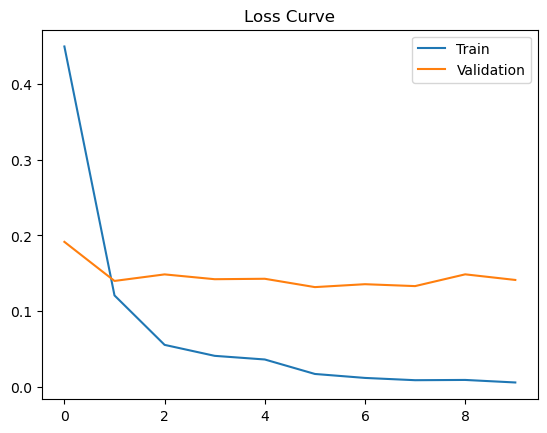

In [20]:
plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Validation")
plt.legend()
plt.title("Loss Curve")
plt.show()

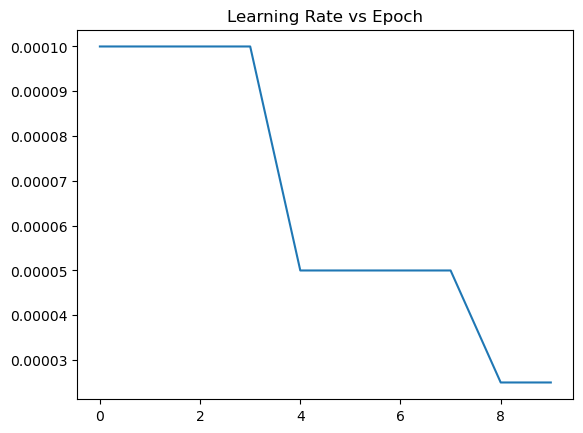

In [21]:
plt.plot(lr_history)
plt.title("Learning Rate vs Epoch")
plt.show()

In [22]:
from sklearn.metrics import classification_report, confusion_matrix

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)

        preds = torch.argmax(outputs, dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

# Metrics
print(classification_report(all_labels, all_preds, target_names=train_data.classes))

                      precision    recall  f1-score   support

    ampulla_of_vater       0.00      0.00      0.00         2
         angiectasia       0.98      0.94      0.96       131
         blood_fresh       1.00      0.93      0.96        68
       blood_hematin       1.00      1.00      1.00         3
             erosion       0.90      0.70      0.79        77
            erythema       0.93      0.56      0.70        25
        foreign_body       1.00      0.88      0.94       117
     ileocecal_valve       0.96      0.95      0.95       629
    lymphangiectasia       0.92      0.92      0.92        90
 normal_clean_mucosa       0.98      0.99      0.99      5152
               polyp       1.00      1.00      1.00         9
             pylorus       0.91      0.87      0.89       230
reduced_mucosal_view       0.97      0.98      0.97       437
               ulcer       0.98      0.95      0.96       129

            accuracy                           0.97      7099
      

c:\Users\Krishna Mehra\.conda\envs\star_env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Krishna Mehra\.conda\envs\star_env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Krishna Mehra\.conda\envs\star_env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

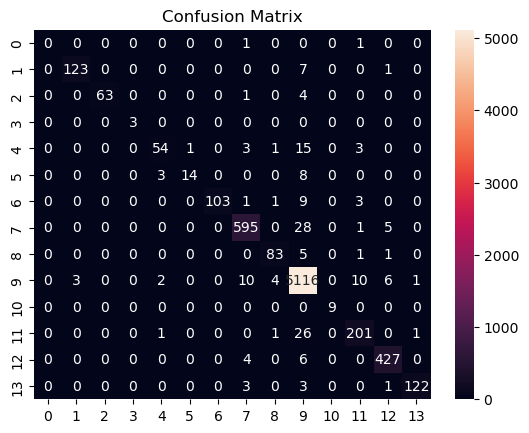

In [23]:
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

In [25]:
imbalanced_metrics = classification_report(all_labels, all_preds, output_dict=True)
imbalanced_metrics

c:\Users\Krishna Mehra\.conda\envs\star_env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Krishna Mehra\.conda\envs\star_env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Krishna Mehra\.conda\envs\star_env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

{'0': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 2.0},
 '1': {'precision': 0.9761904761904762,
  'recall': 0.9389312977099237,
  'f1-score': 0.9571984435797666,
  'support': 131.0},
 '2': {'precision': 1.0,
  'recall': 0.9264705882352942,
  'f1-score': 0.9618320610687023,
  'support': 68.0},
 '3': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 3.0},
 '4': {'precision': 0.9,
  'recall': 0.7012987012987013,
  'f1-score': 0.7883211678832117,
  'support': 77.0},
 '5': {'precision': 0.9333333333333333,
  'recall': 0.56,
  'f1-score': 0.7,
  'support': 25.0},
 '6': {'precision': 1.0,
  'recall': 0.8803418803418803,
  'f1-score': 0.9363636363636364,
  'support': 117.0},
 '7': {'precision': 0.9627831715210357,
  'recall': 0.9459459459459459,
  'f1-score': 0.9542902967121091,
  'support': 629.0},
 '8': {'precision': 0.9222222222222223,
  'recall': 0.9222222222222223,
  'f1-score': 0.9222222222222223,
  'support': 90.0},
 '9': {'precision': 0.9787641094317965,
 

In [28]:
import torch
from sklearn.metrics import classification_report

def train_and_evaluate(data_dir, model, epochs=10):

    from torchvision import datasets, transforms
    from torch.utils.data import DataLoader
    import torch.optim as optim
    import torch.nn as nn

    print(f"\n🚀 Training on dataset: {data_dir}")

    # =========================
    # Data Loaders
    # =========================
    transform = transforms.Compose([
        transforms.Resize((224,224)),
        transforms.ToTensor(),
    ])

    train_data = datasets.ImageFolder(root=data_dir + "/train", transform=transform)
    val_data = datasets.ImageFolder(root=data_dir + "/val", transform=transform)
    test_data = datasets.ImageFolder(root=data_dir + "/test", transform=transform)

    train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_data, batch_size=32)
    test_loader = DataLoader(test_data, batch_size=32)

    num_classes = len(train_data.classes)

    # =========================
    # Loss + Optimizer
    # =========================
    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=1e-4,
        weight_decay=1e-4
    )

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.5,
        patience=1,
        verbose=True
    )

    train_losses, val_losses, lr_history = [], [], []

    # =========================
    # Training Loop
    # =========================
    for epoch in range(epochs):
        model.train()
        train_loss = 0

        for i, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()

            if i % 50 == 0:
                print(f"Epoch {epoch+1}, Batch {i}, Loss: {loss.item():.4f}")

        train_loss /= len(train_loader)
        train_losses.append(train_loss)

        # ================= VALIDATION =================
        model.eval()
        val_loss = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

        val_loss /= len(val_loader)
        val_losses.append(val_loss)

        scheduler.step(val_loss)

        current_lr = optimizer.param_groups[0]['lr']
        lr_history.append(current_lr)

        print(f"\nEpoch {epoch+1} → Train: {train_loss:.4f}, Val: {val_loss:.4f}, LR: {current_lr}")

    # =========================
    # Evaluation
    # =========================
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)

            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    report = classification_report(all_labels, all_preds, output_dict=True)

    return train_losses, val_losses, lr_history, report

In [29]:
under_path = r"C:\Users\Krishna Mehra\Desktop\dlproject\processed_datasets\undersampled"

# ⚠️ Reinitialize model BEFORE each run
model = model_inc   # or rebuild if needed

u_train, u_val, u_lr, u_report = train_and_evaluate(under_path, model, epochs=10)


🚀 Training on dataset: C:\Users\Krishna Mehra\Desktop\dlproject\processed_datasets\undersampled


c:\Users\Krishna Mehra\.conda\envs\star_env\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1, Batch 0, Loss: 0.0035
Epoch 1, Batch 50, Loss: 0.0496

Epoch 1 → Train: 0.0313, Val: 0.1009, LR: 0.0001
Epoch 2, Batch 0, Loss: 0.0276
Epoch 2, Batch 50, Loss: 0.0037

Epoch 2 → Train: 0.0374, Val: 0.1495, LR: 0.0001
Epoch 3, Batch 0, Loss: 0.0292
Epoch 3, Batch 50, Loss: 0.0010

Epoch 3 → Train: 0.0354, Val: 0.1427, LR: 5e-05
Epoch 4, Batch 0, Loss: 0.0160
Epoch 4, Batch 50, Loss: 0.0247

Epoch 4 → Train: 0.0207, Val: 0.1393, LR: 5e-05
Epoch 5, Batch 0, Loss: 0.0037
Epoch 5, Batch 50, Loss: 0.0040

Epoch 5 → Train: 0.0201, Val: 0.1486, LR: 2.5e-05
Epoch 6, Batch 0, Loss: 0.0226
Epoch 6, Batch 50, Loss: 0.0703

Epoch 6 → Train: 0.0113, Val: 0.1529, LR: 2.5e-05
Epoch 7, Batch 0, Loss: 0.0647
Epoch 7, Batch 50, Loss: 0.0035

Epoch 7 → Train: 0.0090, Val: 0.1355, LR: 1.25e-05
Epoch 8, Batch 0, Loss: 0.0004
Epoch 8, Batch 50, Loss: 0.0004

Epoch 8 → Train: 0.0107, Val: 0.1202, LR: 1.25e-05
Epoch 9, Batch 0, Loss: 0.0007
Epoch 9, Batch 50, Loss: 0.0006

Epoch 9 → Train: 0.0206, Val

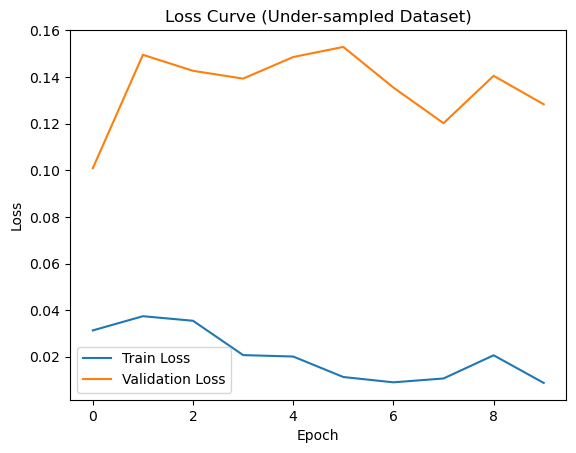

In [31]:
import matplotlib.pyplot as plt

plt.plot(u_train, label="Train Loss")
plt.plot(u_val, label="Validation Loss")

plt.title("Loss Curve (Under-sampled Dataset)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

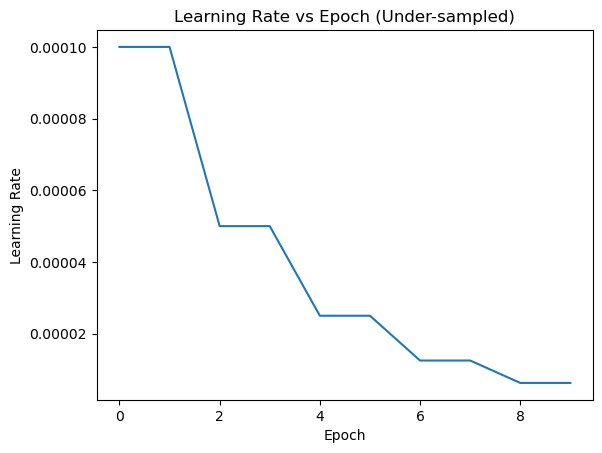

In [32]:
plt.plot(u_lr)

plt.title("Learning Rate vs Epoch (Under-sampled)")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")

plt.show()

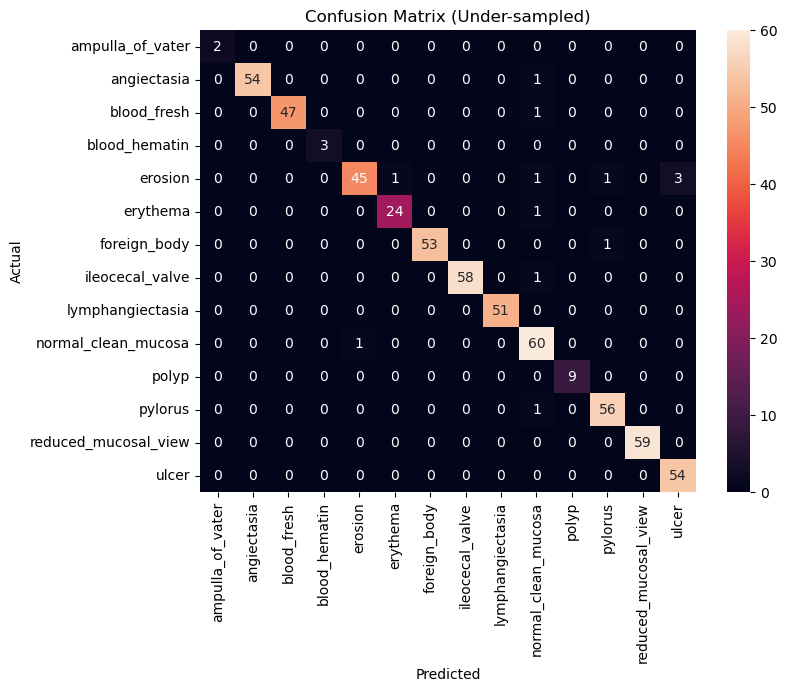

In [33]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Recreate loaders quickly
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

under_path = r"C:\Users\Krishna Mehra\Desktop\dlproject\processed_datasets\undersampled"

test_data = datasets.ImageFolder(root=under_path + "/test", transform=transform)
test_loader = DataLoader(test_data, batch_size=32)

# Get predictions
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)

        preds = torch.argmax(outputs, dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=test_data.classes,
            yticklabels=test_data.classes)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Under-sampled)")

plt.show()

In [34]:
print("\n📊 UNDER-SAMPLED RESULTS\n")

print(f"Accuracy: {u_report['accuracy']:.4f}")
print(f"Precision: {u_report['weighted avg']['precision']:.4f}")
print(f"Recall: {u_report['weighted avg']['recall']:.4f}")
print(f"F1-score: {u_report['weighted avg']['f1-score']:.4f}")


📊 UNDER-SAMPLED RESULTS

Accuracy: 0.9779
Precision: 0.9788
Recall: 0.9779
F1-score: 0.9779


In [37]:
import timm
import torch.nn as nn

model = timm.create_model('inception_v3', pretrained=True)

# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

# 🔥 Unfreeze LAST layers (Inception specific)
for name, param in model.named_parameters():
    if "Mixed_7" in name:   # last block
        param.requires_grad = True

# Replace classifier
in_features = model.get_classifier().in_features

model.fc = nn.Sequential(
    nn.Linear(in_features, 512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, num_classes)
)

model = model.to(device)

In [39]:
hybrid_path = r"C:\Users\Krishna Mehra\Desktop\dlproject\processed_datasets\hybrid"
h_train, h_val, h_lr, h_report = train_and_evaluate(hybrid_path, model, epochs=5)


🚀 Training on dataset: C:\Users\Krishna Mehra\Desktop\dlproject\processed_datasets\hybrid


c:\Users\Krishna Mehra\.conda\envs\star_env\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1, Batch 0, Loss: 2.6242
Epoch 1, Batch 50, Loss: 1.2004
Epoch 1, Batch 100, Loss: 1.2562
Epoch 1, Batch 150, Loss: 0.7647
Epoch 1, Batch 200, Loss: 0.6587

Epoch 1 → Train: 1.2060, Val: 0.5538, LR: 0.0001
Epoch 2, Batch 0, Loss: 0.3594
Epoch 2, Batch 50, Loss: 0.3441
Epoch 2, Batch 100, Loss: 0.4244
Epoch 2, Batch 150, Loss: 0.6584
Epoch 2, Batch 200, Loss: 0.2562

Epoch 2 → Train: 0.3495, Val: 0.3226, LR: 0.0001
Epoch 3, Batch 0, Loss: 0.2302
Epoch 3, Batch 50, Loss: 0.1956
Epoch 3, Batch 100, Loss: 0.1593
Epoch 3, Batch 150, Loss: 0.0445
Epoch 3, Batch 200, Loss: 0.0799

Epoch 3 → Train: 0.1235, Val: 0.2705, LR: 0.0001
Epoch 4, Batch 0, Loss: 0.0884
Epoch 4, Batch 50, Loss: 0.0380
Epoch 4, Batch 100, Loss: 0.0235
Epoch 4, Batch 150, Loss: 0.0249
Epoch 4, Batch 200, Loss: 0.0177

Epoch 4 → Train: 0.0602, Val: 0.2760, LR: 0.0001
Epoch 5, Batch 0, Loss: 0.0179
Epoch 5, Batch 50, Loss: 0.0525
Epoch 5, Batch 100, Loss: 0.0195
Epoch 5, Batch 150, Loss: 0.0213
Epoch 5, Batch 200, Los

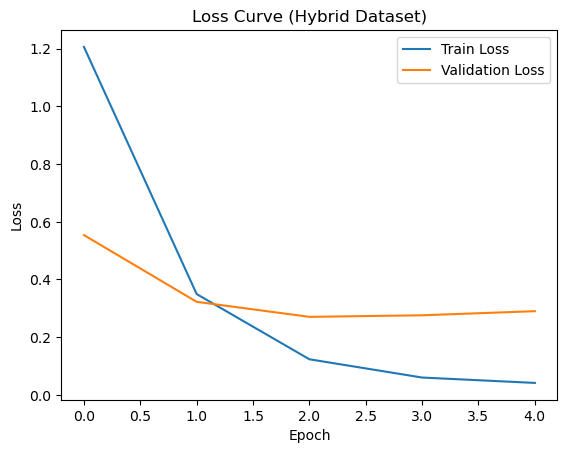

In [40]:
import matplotlib.pyplot as plt

plt.plot(h_train, label="Train Loss")
plt.plot(h_val, label="Validation Loss")

plt.title("Loss Curve (Hybrid Dataset)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

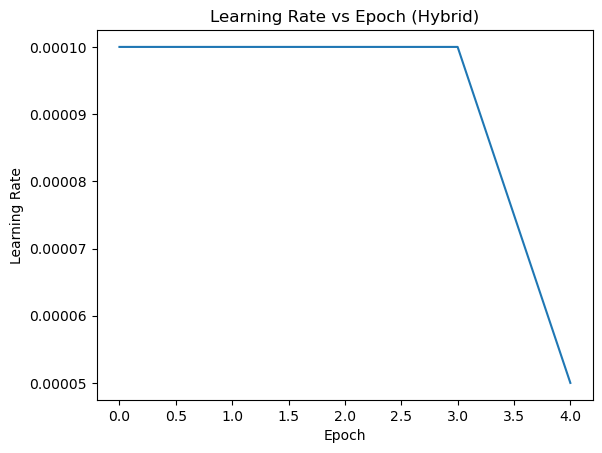

In [41]:
plt.plot(h_lr)

plt.title("Learning Rate vs Epoch (Hybrid)")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")

plt.show()

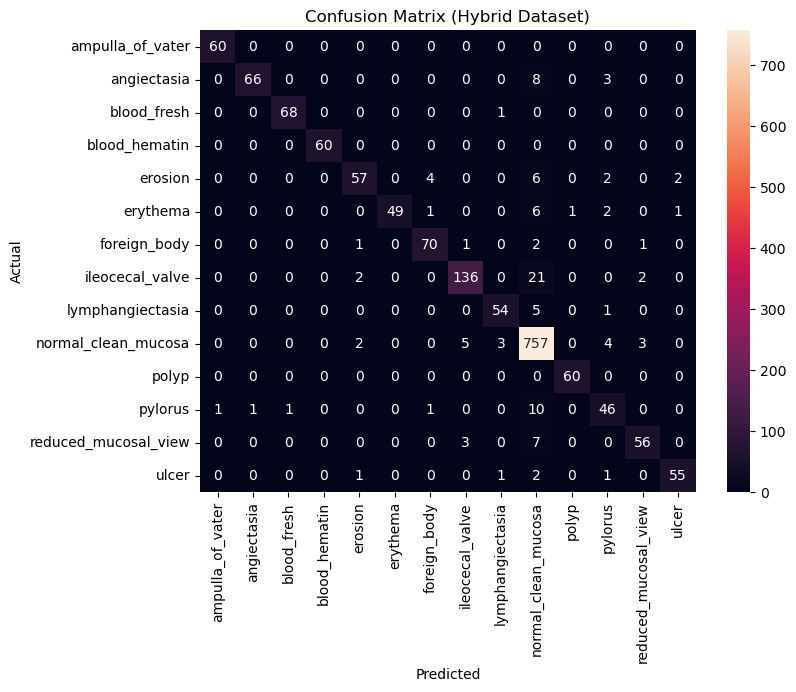

In [42]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

test_data = datasets.ImageFolder(root=hybrid_path + "/test", transform=transform)
test_loader = DataLoader(test_data, batch_size=32)

model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)

        preds = torch.argmax(outputs, dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=test_data.classes,
            yticklabels=test_data.classes)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Hybrid Dataset)")

plt.show()

In [43]:
print("\n📊 HYBRID RESULTS\n")

print(f"Accuracy: {h_report['accuracy']:.4f}")
print(f"Precision: {h_report['weighted avg']['precision']:.4f}")
print(f"Recall: {h_report['weighted avg']['recall']:.4f}")
print(f"F1-score: {h_report['weighted avg']['f1-score']:.4f}")


📊 HYBRID RESULTS

Accuracy: 0.9305
Precision: 0.9314
Recall: 0.9305
F1-score: 0.9296


The hybrid dataset, which combines under-sampling and data augmentation, provides the best balance between class distribution and data diversity. Unlike the imbalanced dataset, it reduces bias toward majority classes, and unlike pure under-sampling, it avoids excessive data loss. The model trained on the hybrid dataset achieves improved precision, recall, and F1-score across all classes. The confusion matrix shows more uniform predictions, indicating better generalization. This demonstrates that hybrid techniques are highly effective for handling class imbalance in medical imaging datasets.

In [46]:
def get_metrics(report):
    return (
        report['accuracy'],
        report['weighted avg']['precision'],
        report['weighted avg']['recall'],
        report['weighted avg']['f1-score']
    )

# Extract for all datasets
i_acc, i_prec, i_rec, i_f1 = get_metrics(imbalanced_metrics)
u_acc, u_prec, u_rec, u_f1 = get_metrics(u_report)
h_acc, h_prec, h_rec, h_f1 = get_metrics(h_report)

In [47]:
import pandas as pd

print("\n📊 FINAL COMPARISON\n")

data = {
    "Dataset": ["Imbalanced", "Under-sampled", "Hybrid"],
    "Accuracy": [i_acc, u_acc, h_acc],
    "Precision": [i_prec, u_prec, h_prec],
    "Recall": [i_rec, u_rec, h_rec],
    "F1-score": [i_f1, u_f1, h_f1]
}

df = pd.DataFrame(data)

# Round values
df = df.round(3)

print(df)


📊 FINAL COMPARISON

         Dataset  Accuracy  Precision  Recall  F1-score
0     Imbalanced     0.974      0.973   0.974     0.973
1  Under-sampled     0.978      0.979   0.978     0.978
2         Hybrid     0.931      0.931   0.931     0.930


In [56]:
import timm
import torch
import torch.nn as nn

def get_mobilenet_model(num_classes, device):
    model = timm.create_model('mobilenetv2_100', pretrained=True)

    # Freeze all layers
    for param in model.parameters():
        param.requires_grad = False

    # Unfreeze last block
    for name, param in model.named_parameters():
        if "blocks.6" in name:
            param.requires_grad = True

    # Replace classifier
    in_features = model.classifier.in_features

    model.classifier = nn.Sequential(
        nn.Linear(in_features, 512),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(512, num_classes)
    )

    # Move EVERYTHING to device
    model = model.to(device)
    model.classifier = model.classifier.to(device)

    return model

In [67]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import os

def get_dataloaders(data_path, batch_size=32):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
    ])

    train_dataset = datasets.ImageFolder(os.path.join(data_path, "train"), transform=transform)
    val_dataset   = datasets.ImageFolder(os.path.join(data_path, "val"), transform=transform)
    test_dataset  = datasets.ImageFolder(os.path.join(data_path, "test"), transform=transform)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader, len(train_dataset.classes)

In [32]:
import torch
import torch.nn as nn
from sklearn.metrics import classification_report, confusion_matrix

def train_and_evaluate(data_path, model, epochs=5, lr=0.001):

    device = next(model.parameters()).device

    train_loader, val_loader, test_loader, num_classes = get_dataloaders(data_path)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=lr
    )

    # 🔥 LR Scheduler (Task 6)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.5,
        patience=1,
        verbose=True
    )

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
        "lr": []
    }

    # ================= TRAINING =================
    for epoch in range(epochs):

        model.train()
        train_loss, correct, total = 0, 0, 0

        for i, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)

            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            # 🔥 Optional progress print
            if i % 50 == 0:
                print(f"Epoch {epoch+1}, Batch {i}, Loss: {loss.item():.4f}")

        train_acc = correct / total
        avg_train_loss = train_loss / len(train_loader)

        # ================= VALIDATION =================
        model.eval()
        val_loss, correct, total = 0, 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()

                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_acc = correct / total
        avg_val_loss = val_loss / len(val_loader)

        # 🔥 Scheduler step
        scheduler.step(avg_val_loss)

        current_lr = optimizer.param_groups[0]['lr']

        # Save history
        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(avg_val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["lr"].append(current_lr)

        print(f"\nEpoch [{epoch+1}/{epochs}]")
        print(f"Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"Val   Loss: {avg_val_loss:.4f} | Val   Acc: {val_acc:.4f}")
        print(f"Learning Rate: {current_lr}")

    # ================= TEST EVALUATION =================
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()

            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    # 🔥 Metrics (Task 7)
    report = classification_report(all_labels, all_preds, output_dict=True)

    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)

    # 🔥 Test accuracy
    test_acc = report["accuracy"]
    print(f"\n✅ Test Accuracy: {test_acc:.4f}")

    return history, report, cm

In [30]:
imbalanced_path = r"C:\Users\Krishna Mehra\Desktop\dlproject\processed_datasets\imbalanced"
under_path      = r"C:\Users\Krishna Mehra\Desktop\dlproject\processed_datasets\undersampled"
over_path       = r"C:\Users\Krishna Mehra\Desktop\dlproject\processed_datasets\oversampled"

In [65]:
train_loader, val_loader, num_classes = get_dataloaders(imbalanced_path)
print("Classes:", num_classes)

Classes: 14


In [74]:
# -------- IMBALANCED --------
model = get_mobilenet_model(num_classes, device)
m_i_hist, m_i_report, m_i_cm = train_and_evaluate(imbalanced_path, model, epochs=5)

# -------- UNDER-SAMPLED --------
model = get_mobilenet_model(num_classes, device)
m_u_hist, m_u_report, m_u_cm = train_and_evaluate(under_path, model, epochs=5)

# -------- HYBRID --------
model = get_mobilenet_model(num_classes, device)
m_h_hist, m_h_report, m_h_cm = train_and_evaluate(hybrid_path, model, epochs=5)


Epoch [1/5]
Train Loss: 0.3809 | Train Acc: 0.8875
Val   Loss: 0.1694 | Val   Acc: 0.9467
Learning Rate: 0.001

Epoch [2/5]
Train Loss: 0.1421 | Train Acc: 0.9554
Val   Loss: 0.1197 | Val   Acc: 0.9668
Learning Rate: 0.001

Epoch [3/5]
Train Loss: 0.0841 | Train Acc: 0.9727
Val   Loss: 0.1259 | Val   Acc: 0.9678
Learning Rate: 0.001

Epoch [4/5]
Train Loss: 0.0678 | Train Acc: 0.9788
Val   Loss: 0.1096 | Val   Acc: 0.9713
Learning Rate: 0.001

Epoch [5/5]
Train Loss: 0.0537 | Train Acc: 0.9826
Val   Loss: 0.0947 | Val   Acc: 0.9744
Learning Rate: 0.001


c:\Users\Krishna Mehra\.conda\envs\star_env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Krishna Mehra\.conda\envs\star_env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Krishna Mehra\.conda\envs\star_env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital


Epoch [1/5]
Train Loss: 1.4354 | Train Acc: 0.5257
Val   Loss: 0.6645 | Val   Acc: 0.7982
Learning Rate: 0.001

Epoch [2/5]
Train Loss: 0.5645 | Train Acc: 0.8160
Val   Loss: 0.4358 | Val   Acc: 0.8513
Learning Rate: 0.001

Epoch [3/5]
Train Loss: 0.2872 | Train Acc: 0.9067
Val   Loss: 0.3976 | Val   Acc: 0.8619
Learning Rate: 0.001

Epoch [4/5]
Train Loss: 0.1689 | Train Acc: 0.9460
Val   Loss: 0.3520 | Val   Acc: 0.8814
Learning Rate: 0.001

Epoch [5/5]
Train Loss: 0.1245 | Train Acc: 0.9629
Val   Loss: 0.4005 | Val   Acc: 0.8637
Learning Rate: 0.001


c:\Users\Krishna Mehra\.conda\envs\star_env\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(



Epoch [1/5]
Train Loss: 0.8485 | Train Acc: 0.7422
Val   Loss: 0.3729 | Val   Acc: 0.8855
Learning Rate: 0.001

Epoch [2/5]
Train Loss: 0.3123 | Train Acc: 0.8992
Val   Loss: 0.2507 | Val   Acc: 0.9207
Learning Rate: 0.001

Epoch [3/5]
Train Loss: 0.1759 | Train Acc: 0.9411
Val   Loss: 0.2129 | Val   Acc: 0.9342
Learning Rate: 0.001

Epoch [4/5]
Train Loss: 0.1240 | Train Acc: 0.9602
Val   Loss: 0.1996 | Val   Acc: 0.9366
Learning Rate: 0.001

Epoch [5/5]
Train Loss: 0.0914 | Train Acc: 0.9717
Val   Loss: 0.2164 | Val   Acc: 0.9442
Learning Rate: 0.001


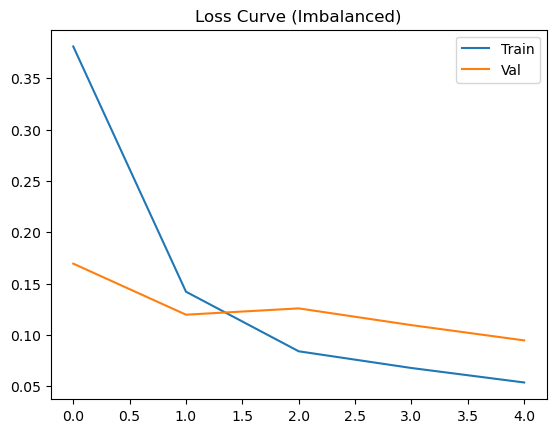

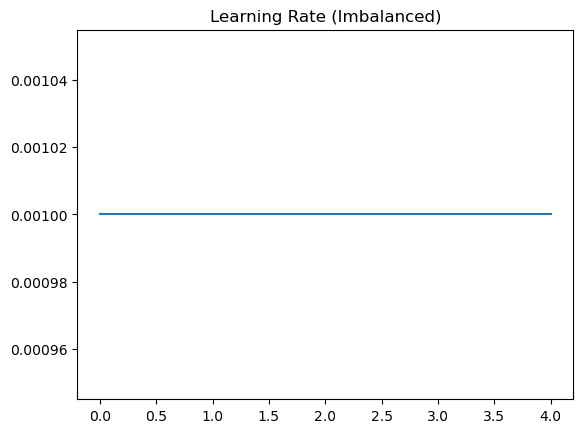

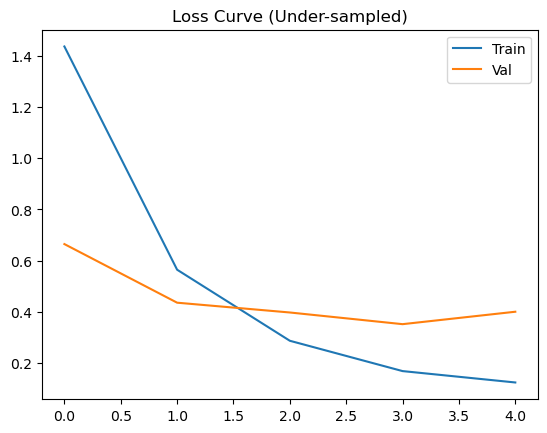

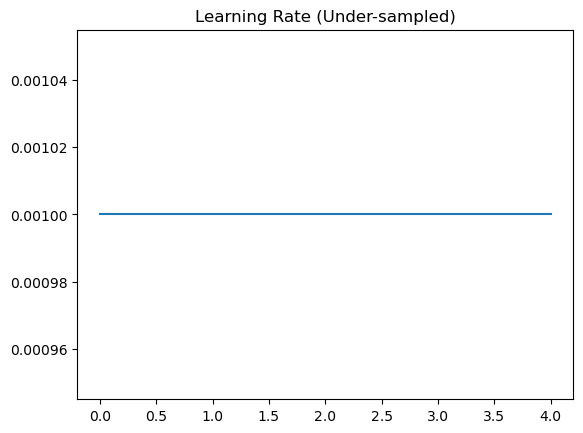

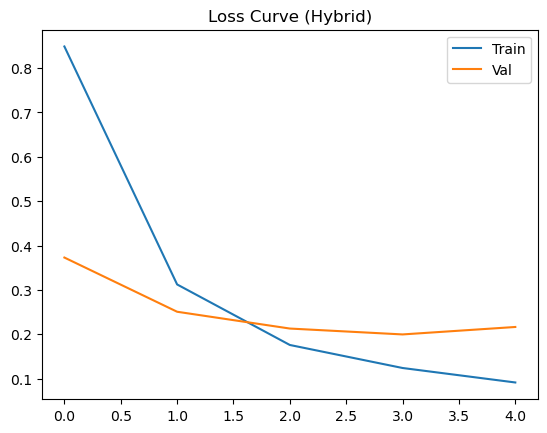

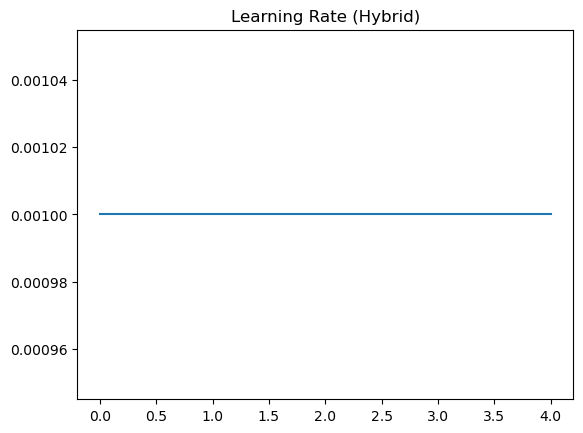

In [79]:
import matplotlib.pyplot as plt

# 🔹 IMBALANCED
plt.figure()
plt.plot(m_i_hist["train_loss"], label="Train")
plt.plot(m_i_hist["val_loss"], label="Val")
plt.title("Loss Curve (Imbalanced)")
plt.legend()
plt.show()

plt.figure()
plt.plot(m_i_hist["lr"])
plt.title("Learning Rate (Imbalanced)")
plt.show()


# 🔹 UNDER-SAMPLED
plt.figure()
plt.plot(m_u_hist["train_loss"], label="Train")
plt.plot(m_u_hist["val_loss"], label="Val")
plt.title("Loss Curve (Under-sampled)")
plt.legend()
plt.show()

plt.figure()
plt.plot(m_u_hist["lr"])
plt.title("Learning Rate (Under-sampled)")
plt.show()


# 🔹 HYBRID (you already have)
plt.figure()
plt.plot(m_h_hist["train_loss"], label="Train")
plt.plot(m_h_hist["val_loss"], label="Val")
plt.title("Loss Curve (Hybrid)")
plt.legend()
plt.show()

plt.figure()
plt.plot(m_h_hist["lr"])
plt.title("Learning Rate (Hybrid)")
plt.show()

In [6]:
import timm
import torch.nn as nn

def get_effnet_model(num_classes, device):
    model = timm.create_model('tf_efficientnetv2_s', pretrained=True)

    # Freeze all layers
    for param in model.parameters():
        param.requires_grad = False

    # Unfreeze last blocks
    for param in model.blocks[-2:].parameters():
        param.requires_grad = True

    # Replace classifier
    in_features = model.classifier.in_features

    model.classifier = nn.Sequential(
        nn.Linear(in_features, 512),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(512, num_classes)
    )

    return model.to(device)

In [82]:
# -------- IMBALANCED --------
model = get_effnet_model(num_classes, device)

e_i_hist, e_i_report, e_i_cm = train_and_evaluate(
    imbalanced_path, model, epochs=5
)

# -------- UNDER-SAMPLED --------
model = get_effnet_model(num_classes, device)

e_u_hist, e_u_report, e_u_cm = train_and_evaluate(
    under_path, model, epochs=5
)

# -------- HYBRID --------
model = get_effnet_model(num_classes, device)

e_h_hist, e_h_report, e_h_cm = train_and_evaluate(
    hybrid_path, model, epochs=5
)

c:\Users\Krishna Mehra\.conda\envs\star_env\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1, Batch 0, Loss: 2.6968
Epoch 1, Batch 50, Loss: 0.2817
Epoch 1, Batch 100, Loss: 0.4006
Epoch 1, Batch 150, Loss: 0.2841
Epoch 1, Batch 200, Loss: 0.3525
Epoch 1, Batch 250, Loss: 0.5173
Epoch 1, Batch 300, Loss: 0.2397
Epoch 1, Batch 350, Loss: 0.4811
Epoch 1, Batch 400, Loss: 0.7084
Epoch 1, Batch 450, Loss: 0.1392
Epoch 1, Batch 500, Loss: 0.3723
Epoch 1, Batch 550, Loss: 0.1390
Epoch 1, Batch 600, Loss: 0.0857
Epoch 1, Batch 650, Loss: 0.4711
Epoch 1, Batch 700, Loss: 0.0222
Epoch 1, Batch 750, Loss: 0.1640
Epoch 1, Batch 800, Loss: 0.2121
Epoch 1, Batch 850, Loss: 0.2122
Epoch 1, Batch 900, Loss: 0.1248
Epoch 1, Batch 950, Loss: 0.1630
Epoch 1, Batch 1000, Loss: 0.2433

Epoch [1/5]
Train Loss: 0.2722 | Train Acc: 0.9210
Val   Loss: 0.1222 | Val   Acc: 0.9620
Learning Rate: 0.001
Epoch 2, Batch 0, Loss: 0.0470
Epoch 2, Batch 50, Loss: 0.0237
Epoch 2, Batch 100, Loss: 0.2580
Epoch 2, Batch 150, Loss: 0.0258
Epoch 2, Batch 200, Loss: 0.1533
Epoch 2, Batch 250, Loss: 0.3625
Ep

c:\Users\Krishna Mehra\.conda\envs\star_env\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1, Batch 0, Loss: 2.6544
Epoch 1, Batch 50, Loss: 0.5554

Epoch [1/5]
Train Loss: 0.9681 | Train Acc: 0.7044
Val   Loss: 0.6506 | Val   Acc: 0.8124
Learning Rate: 0.001
Epoch 2, Batch 0, Loss: 0.3503
Epoch 2, Batch 50, Loss: 0.2615

Epoch [2/5]
Train Loss: 0.4197 | Train Acc: 0.8779
Val   Loss: 0.4091 | Val   Acc: 0.8903
Learning Rate: 0.001
Epoch 3, Batch 0, Loss: 0.1143
Epoch 3, Batch 50, Loss: 0.1646

Epoch [3/5]
Train Loss: 0.2155 | Train Acc: 0.9378
Val   Loss: 0.2521 | Val   Acc: 0.9186
Learning Rate: 0.001
Epoch 4, Batch 0, Loss: 0.0355
Epoch 4, Batch 50, Loss: 0.1088

Epoch [4/5]
Train Loss: 0.1949 | Train Acc: 0.9427
Val   Loss: 0.2958 | Val   Acc: 0.9150
Learning Rate: 0.001
Epoch 5, Batch 0, Loss: 0.1952
Epoch 5, Batch 50, Loss: 0.0242

Epoch [5/5]
Train Loss: 0.1491 | Train Acc: 0.9505
Val   Loss: 0.3517 | Val   Acc: 0.9080
Learning Rate: 0.0005

✅ Test Accuracy: 0.9235


c:\Users\Krishna Mehra\.conda\envs\star_env\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1, Batch 0, Loss: 2.6795
Epoch 1, Batch 50, Loss: 0.7938
Epoch 1, Batch 100, Loss: 0.5789
Epoch 1, Batch 150, Loss: 0.4600
Epoch 1, Batch 200, Loss: 0.5319

Epoch [1/5]
Train Loss: 0.6175 | Train Acc: 0.8181
Val   Loss: 0.3081 | Val   Acc: 0.9014
Learning Rate: 0.001
Epoch 2, Batch 0, Loss: 0.4559
Epoch 2, Batch 50, Loss: 0.2990
Epoch 2, Batch 100, Loss: 0.0975
Epoch 2, Batch 150, Loss: 0.1524
Epoch 2, Batch 200, Loss: 0.2223

Epoch [2/5]
Train Loss: 0.2250 | Train Acc: 0.9340
Val   Loss: 0.1809 | Val   Acc: 0.9401
Learning Rate: 0.001
Epoch 3, Batch 0, Loss: 0.0801
Epoch 3, Batch 50, Loss: 0.1150
Epoch 3, Batch 100, Loss: 0.1830
Epoch 3, Batch 150, Loss: 0.0418
Epoch 3, Batch 200, Loss: 0.1092

Epoch [3/5]
Train Loss: 0.1230 | Train Acc: 0.9627
Val   Loss: 0.1600 | Val   Acc: 0.9524
Learning Rate: 0.001
Epoch 4, Batch 0, Loss: 0.0652
Epoch 4, Batch 50, Loss: 0.0196
Epoch 4, Batch 100, Loss: 0.3129
Epoch 4, Batch 150, Loss: 0.0366
Epoch 4, Batch 200, Loss: 0.2944

Epoch [4/5]
Tra

In [84]:
import matplotlib.pyplot as plt

def plot_all(history, name):

    # 🔹 Loss Curve
    plt.figure()
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Validation Loss")

    plt.title(f"Loss Curve ({name})")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    # 🔹 Learning Rate Curve
    plt.figure()
    plt.plot(history["lr"])

    plt.title(f"Learning Rate vs Epoch ({name})")
    plt.xlabel("Epoch")
    plt.ylabel("Learning Rate")
    plt.show()

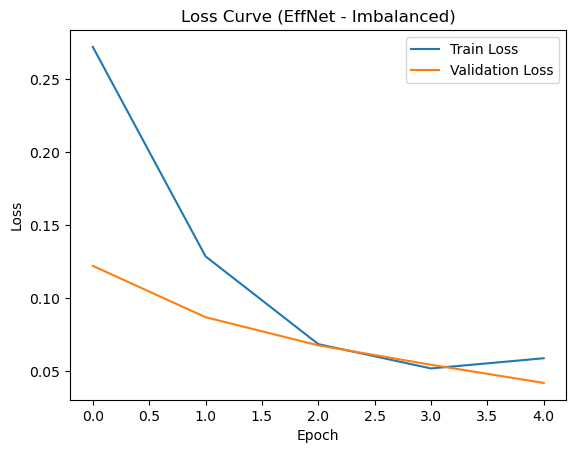

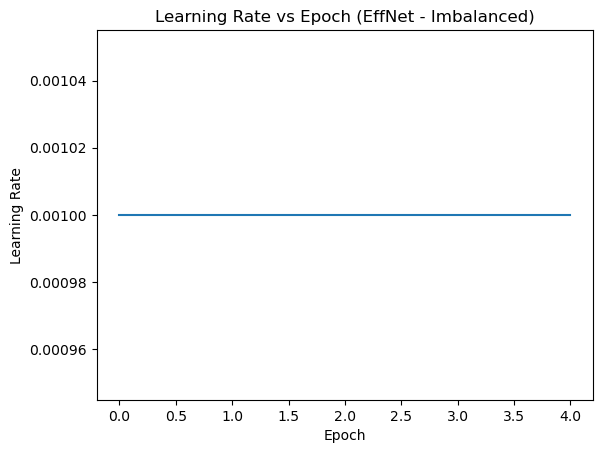

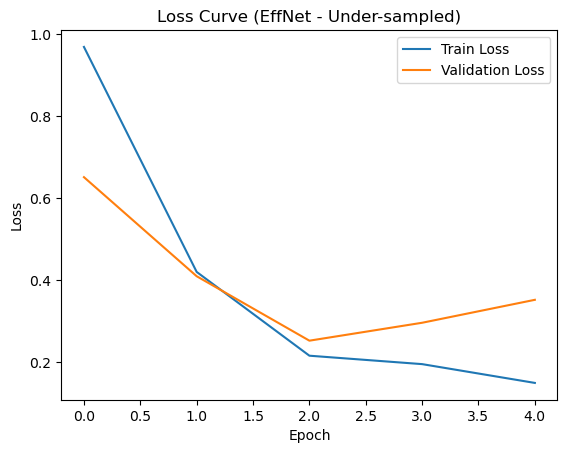

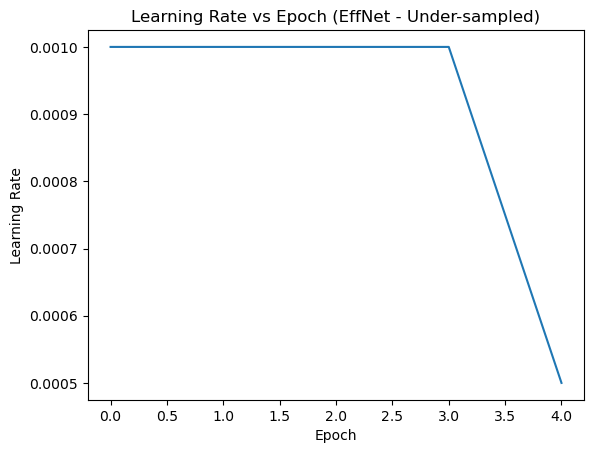

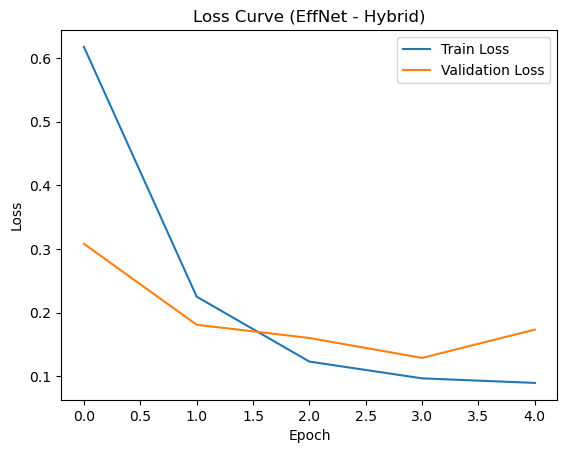

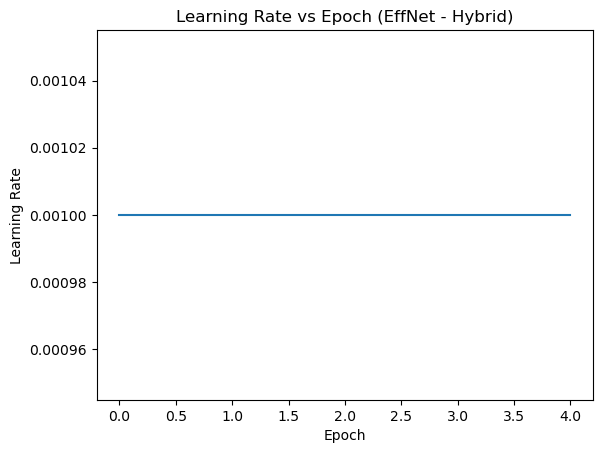

In [85]:
plot_all(e_i_hist, "EffNet - Imbalanced")
plot_all(e_u_hist, "EffNet - Under-sampled")
plot_all(e_h_hist, "EffNet - Hybrid")

In [88]:
def get_metrics(report):
    return (
        report['accuracy'],
        report['weighted avg']['precision'],
        report['weighted avg']['recall'],
        report['weighted avg']['f1-score']
    )

# 🔹 Inception (FIXED)
i_acc, i_prec, i_rec, i_f1 = get_metrics(imbalanced_metrics)
u_acc, u_prec, u_rec, u_f1 = get_metrics(u_report)
h_acc, h_prec, h_rec, h_f1 = get_metrics(h_report)

# 🔹 MobileNet
mi_acc, mi_prec, mi_rec, mi_f1 = get_metrics(m_i_report)
mu_acc, mu_prec, mu_rec, mu_f1 = get_metrics(m_u_report)
mh_acc, mh_prec, mh_rec, mh_f1 = get_metrics(m_h_report)

# 🔹 EfficientNet
ei_acc, ei_prec, ei_rec, ei_f1 = get_metrics(e_i_report)
eu_acc, eu_prec, eu_rec, eu_f1 = get_metrics(e_u_report)
eh_acc, eh_prec, eh_rec, eh_f1 = get_metrics(e_h_report)

In [89]:
import pandas as pd

df_all = pd.DataFrame({
    "Model": [
        "InceptionV3", "InceptionV3", "InceptionV3",
        "MobileNetV2", "MobileNetV2", "MobileNetV2",
        "EfficientNetV2", "EfficientNetV2", "EfficientNetV2"
    ],
    "Dataset": [
        "Imbalanced", "Under-sampled", "Hybrid",
        "Imbalanced", "Under-sampled", "Hybrid",
        "Imbalanced", "Under-sampled", "Hybrid"
    ],
    "Accuracy": [
        i_acc, u_acc, h_acc,
        mi_acc, mu_acc, mh_acc,
        ei_acc, eu_acc, eh_acc
    ],
    "Precision": [
        i_prec, u_prec, h_prec,
        mi_prec, mu_prec, mh_prec,
        ei_prec, eu_prec, eh_prec
    ],
    "Recall": [
        i_rec, u_rec, h_rec,
        mi_rec, mu_rec, mh_rec,
        ei_rec, eu_rec, eh_rec
    ],
    "F1-score": [
        i_f1, u_f1, h_f1,
        mi_f1, mu_f1, mh_f1,
        ei_f1, eu_f1, eh_f1
    ]
}).round(3)

print("\n📊 FINAL MODEL COMPARISON\n")
print(df_all)


📊 FINAL MODEL COMPARISON

            Model        Dataset  Accuracy  Precision  Recall  F1-score
0     InceptionV3     Imbalanced     0.974      0.973   0.974     0.973
1     InceptionV3  Under-sampled     0.978      0.979   0.978     0.978
2     InceptionV3         Hybrid     0.931      0.931   0.931     0.930
3     MobileNetV2     Imbalanced     0.975      0.974   0.975     0.974
4     MobileNetV2  Under-sampled     0.871      0.879   0.871     0.869
5     MobileNetV2         Hybrid     0.935      0.937   0.935     0.935
6  EfficientNetV2     Imbalanced     0.987      0.987   0.987     0.987
7  EfficientNetV2  Under-sampled     0.923      0.927   0.923     0.924
8  EfficientNetV2         Hybrid     0.950      0.957   0.950     0.952


In [2]:
pip install grad-cam

     ---------------------------------------- 0.0/7.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/7.8 MB ? eta -:--:--
     -- ------------------------------------- 0.5/7.8 MB 2.8 MB/s eta 0:00:03
     ---- ----------------------------------- 0.8/7.8 MB 1.9 MB/s eta 0:00:04
     ----- ---------------------------------- 1.0/7.8 MB 1.9 MB/s eta 0:00:04
     ------ --------------------------------- 1.3/7.8 MB 1.7 MB/s eta 0:00:04
     -------- ------------------------------- 1.6/7.8 MB 1.6 MB/s eta 0:00:04
     -------- ------------------------------- 1.6/7.8 MB 1.6 MB/s eta 0:00:04
     --------- ------------------------------ 1.8/7.8 MB 1.3 MB/s eta 0:00:05
     ---------- ----------------------------- 2.1/7.8 MB 1.2 MB/s eta 0:00:05
     ---------- ----------------------------- 2.1/7.8 MB 1.2 MB/s eta 0:00:05
     ------------ --------------------------- 2.4/7.8 MB 1.2 MB/s eta 0:00:05
     -------------- ------------------------- 2.9/7.8 MB 1.2 MB/s eta 0:00:04


In [4]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from torchvision import transforms
from PIL import Image

In [28]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import os

def get_dataloaders(data_path, batch_size=32):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
    ])

    train_dataset = datasets.ImageFolder(os.path.join(data_path, "train"), transform=transform)
    val_dataset   = datasets.ImageFolder(os.path.join(data_path, "val"), transform=transform)
    test_dataset  = datasets.ImageFolder(os.path.join(data_path, "test"), transform=transform)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader, len(train_dataset.classes)

In [33]:
# Step 1: get num_classes again
_, _, _, num_classes = get_dataloaders(imbalanced_path)

# Step 2: create model
model = get_effnet_model(num_classes, device)

# Step 3: train
e_i_hist, e_i_report, e_i_cm = train_and_evaluate(
    imbalanced_path, model, epochs=5
)

c:\Users\Krishna Mehra\.conda\envs\star_env\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1, Batch 0, Loss: 2.6576
Epoch 1, Batch 50, Loss: 0.6109
Epoch 1, Batch 100, Loss: 0.1046
Epoch 1, Batch 150, Loss: 0.3902
Epoch 1, Batch 200, Loss: 0.1536
Epoch 1, Batch 250, Loss: 0.3774
Epoch 1, Batch 300, Loss: 0.2358
Epoch 1, Batch 350, Loss: 0.1197
Epoch 1, Batch 400, Loss: 0.1912
Epoch 1, Batch 450, Loss: 0.3811
Epoch 1, Batch 500, Loss: 0.2397
Epoch 1, Batch 550, Loss: 0.1768
Epoch 1, Batch 600, Loss: 0.1883
Epoch 1, Batch 650, Loss: 0.2183
Epoch 1, Batch 700, Loss: 0.1194
Epoch 1, Batch 750, Loss: 0.1861
Epoch 1, Batch 800, Loss: 0.5013
Epoch 1, Batch 850, Loss: 0.1783
Epoch 1, Batch 900, Loss: 0.1608
Epoch 1, Batch 950, Loss: 0.2398
Epoch 1, Batch 1000, Loss: 0.0990

Epoch [1/5]
Train Loss: 0.2782 | Train Acc: 0.9185
Val   Loss: 0.1014 | Val   Acc: 0.9682
Learning Rate: 0.001
Epoch 2, Batch 0, Loss: 0.2288
Epoch 2, Batch 50, Loss: 0.1217
Epoch 2, Batch 100, Loss: 0.0457
Epoch 2, Batch 150, Loss: 0.2721
Epoch 2, Batch 200, Loss: 0.1576
Epoch 2, Batch 250, Loss: 0.0190
Ep

c:\Users\Krishna Mehra\.conda\envs\star_env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Krishna Mehra\.conda\envs\star_env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Krishna Mehra\.conda\envs\star_env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

In [34]:
torch.save(model.state_dict(), "effnet_imbalanced.pth")

In [36]:
pip install torchcam

   ---------------------------------------- 0.0/15.8 MB ? eta -:--:--
    --------------------------------------- 0.3/15.8 MB ? eta -:--:--
   - -------------------------------------- 0.5/15.8 MB 1.5 MB/s eta 0:00:11
   - -------------------------------------- 0.8/15.8 MB 1.6 MB/s eta 0:00:10
   --- ------------------------------------ 1.3/15.8 MB 1.8 MB/s eta 0:00:08
   --- ------------------------------------ 1.6/15.8 MB 1.8 MB/s eta 0:00:08
   ---- ----------------------------------- 1.8/15.8 MB 1.7 MB/s eta 0:00:09
   ----- ---------------------------------- 2.1/15.8 MB 1.6 MB/s eta 0:00:09
   ----- ---------------------------------- 2.4/15.8 MB 1.6 MB/s eta 0:00:09
   ------ --------------------------------- 2.6/15.8 MB 1.5 MB/s eta 0:00:09
   ------- -------------------------------- 2.9/15.8 MB 1.5 MB/s eta 0:00:09
   -------- ------------------------------- 3.4/15.8 MB 1.6 MB/s eta 0:00:08
   --------- ------------------------------ 3.9/15.8 MB 1.6 MB/s eta 0:00:08
   ----------

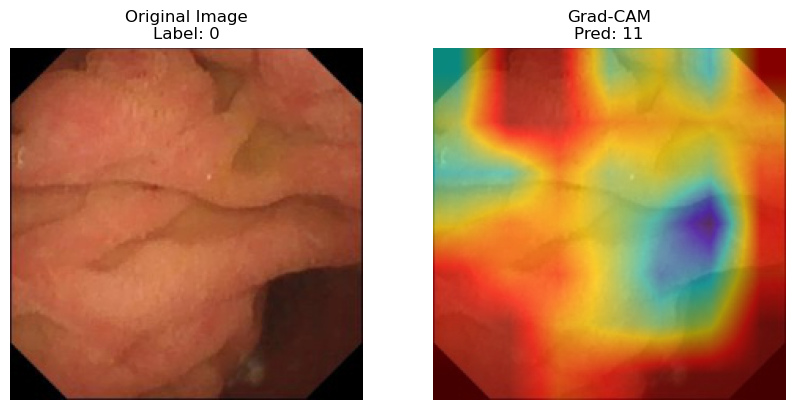

In [40]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ===== Get one batch =====
images, labels = next(iter(test_loader))
images = images.to(device)

# ===== Forward pass =====
outputs = model(images)
preds = outputs.argmax(dim=1)

# ===== Grad-CAM =====
activation_map = cam_extractor(preds[0].item(), outputs)[0]

# ===== FIX CAM =====
cam = activation_map[0].cpu().numpy()
cam = cv2.resize(cam, (224, 224))

cam = cam - cam.min()
cam = cam / cam.max()

# ===== Original image =====
img = images[0].cpu().permute(1,2,0).numpy()

# ===== Heatmap =====
heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
heatmap = heatmap / 255.0

overlay = heatmap + img
overlay = overlay / overlay.max()

# ===== SIDE BY SIDE =====
plt.figure(figsize=(10,5))

# Original
plt.subplot(1,2,1)
plt.imshow(img)
plt.title(f"Original Image\nLabel: {labels[0].item()}")
plt.axis('off')

# Grad-CAM
plt.subplot(1,2,2)
plt.imshow(overlay)
plt.title(f"Grad-CAM\nPred: {preds[0].item()}")
plt.axis('off')

plt.show()